# EDA (Exploratory Data Analysis)

EDA on **Global Michelin-Starred Restaurants Dataset**.


1. Load dataset and libraries  
2. Clean data (missing values, duplicates, data types, outliers)  
3. Univariate analysis (single variable distributions)  
4. Bivariate & multivariate analysis (relationships between variables)  
5. Outlier detection (IQR method)  
6. Feature Engineering  
7. Key Insights


## 1. Load Libraries & Dataset

> 🔹 **Note:** Change the CSV file name in the code below if your file has a different name.


In [ ]:
# 1. Load libraries & Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: nicer plots
sns.set(style="whitegrid")

# Load dataset (change the file name if needed)
df = pd.read_csv("49bde7b6-d328-4707-8e52-c8707c33dc84.csv")

# Preview
df.head()

## 2. Basic Information and Overview

In [ ]:
# Shape of the dataset
print("Shape of dataset:", df.shape)

# Column info
print("\nData Info:")
df.info()

# Summary statistics for numeric & categorical columns
print("\nSummary Statistics (numeric / categorical):")
df.describe(include="all").T

## 3. Missing Value Analysis

In [ ]:
# Missing value count & percentage
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2)
})

missing = missing.sort_values(by="missing_percent", ascending=False)
missing

## 4. Duplicate Rows

In [ ]:
# Check for duplicate rows
dup_count = df.duplicated().sum()
print("Number of duplicate rows:", dup_count)

# If any duplicates, remove them
if dup_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates dropped. New shape:", df.shape)
else:
    print("No duplicate rows found.")

## 5. Data Types & Basic Transformations

In [ ]:
# Check data types
df.dtypes

In [ ]:
# Example: convert 'Established_Year' to integer (if not already)
if df["Established_Year"].dtype != "int64":
    df["Established_Year"] = df["Established_Year"].astype(int)

# Example: ensure 'Michelin_Stars' is integer
if df["Michelin_Stars"].dtype != "int64":
    df["Michelin_Stars"] = df["Michelin_Stars"].astype(int)

df.dtypes

## 6. Univariate Analysis

In [ ]:
# List numeric and categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", cat_cols)

In [ ]:
# Histograms for numeric features
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col].dropna(), bins=10)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

In [ ]:
# Countplots for categorical features (top categories if many)
for col in cat_cols:
    plt.figure(figsize=(8,4))
    vc = df[col].value_counts()
    vc.plot(kind="bar")
    plt.title(f"Category counts: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

## 7. Bivariate / Multivariate Analysis

In [ ]:
# Correlation matrix for numeric variables
corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()

In [ ]:
# Example 1: Average price vs Rating
plt.figure(figsize=(6,4))
plt.scatter(df["Average_Price_USD"], df["Rating"])
plt.title("Average Price vs Rating")
plt.xlabel("Average Price (USD)")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()

In [ ]:
# Example 2: Boxplot of Average Price by Price Category
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x="Price_Category", y="Average_Price_USD")
plt.title("Average Price by Price Category")
plt.tight_layout()
plt.show()

In [ ]:
# Example 3: Count of restaurants by Continent and Star Category
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="Continent", hue="Star_Category")
plt.title("Restaurant Count by Continent & Star Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8. Outlier Detection using IQR (Numeric Columns)

In [ ]:
# IQR-based outlier detection function
def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask = (series < lower) | (series > upper)
    return mask, lower, upper

outlier_summary = {}

for col in numeric_cols:
    mask, lower, upper = detect_outliers_iqr(df[col])
    count_outliers = mask.sum()
    outlier_summary[col] = {
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": int(count_outliers)
    }

pd.DataFrame(outlier_summary).T

In [ ]:
# Optionally: cap outliers (winsorization-style) for a specific column
col = "Average_Price_USD"
mask, lower, upper = detect_outliers_iqr(df[col])

print(f"Outliers in {col} before capping:", mask.sum())

df.loc[df[col] < lower, col] = lower
df.loc[df[col] > upper, col] = upper

mask_after, _, _ = detect_outliers_iqr(df[col])
print(f"Outliers in {col} after capping:", mask_after.sum())

## 9. Feature Engineering

In [ ]:
# Example Feature 1: Price bucket from Average_Price_USD
bins = [0, 150, 300, 500, np.inf]
labels = ["Budget", "Mid-Range", "Premium", "Ultra-Premium"]
df["Price_Bucket"] = pd.cut(df["Average_Price_USD"], bins=bins, labels=labels)

# Example Feature 2: Age of restaurant (same as Years_Operating but recomputed from current year)
CURRENT_YEAR = 2025
df["Computed_Years_Operating"] = CURRENT_YEAR - df["Established_Year"]

# Example Feature 3: Is ultra luxury flag
df["Is_Ultra_Luxury"] = df["Price_Category"].eq("Ultra-Luxury").astype(int)

df.head()

## 10. Key Insights (Example)

**Example Insights – Update these based on your observations:**

1. Most restaurants fall under the **Luxury / Ultra-Luxury** price categories with high average prices in USD.  
2. The dataset mainly contains **3-star Michelin restaurants**, with high ratings (mostly above 4.5).  
3. There is a **moderate relationship** between `Average_Price_USD` and `Rating` (you can interpret this from the scatter plot & correlations).  
4. European countries seem to dominate the list of top restaurants (check `Country` and `Continent` distributions).  
5. Older restaurants (higher `Years_Operating`) may or may not have higher ratings – you can verify this using scatter plots.


## 11. Export Cleaned / Engineered Dataset

In [ ]:
# Export the cleaned and feature-engineered data
output_file = "Michelin_Restaurants_Cleaned_FE.csv"
df.to_csv(output_file, index=False)
print(f"Cleaned & engineered data saved as: {output_file}")

# ✅ Additional Steps Added from Your Provided Notebook

In [1]:
import pandas as pd
df=pd.read_csv("loan_approved.csv")

In [2]:
df.shape


(614, 13)

In [3]:
df.head(20)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Loan_ID                 614 non-null    object 
 1   Gender                  601 non-null    object 
 2   Married                 611 non-null    object 
 3   Dependents              599 non-null    object 
 4   Education               614 non-null    object 
 5   Self_Employed           582 non-null    object 
 6   ApplicantIncome         614 non-null    int64  
 7   CoapplicantIncome       614 non-null    float64
 8   LoanAmount              592 non-null    float64
 9   Loan_Amount_Term        600 non-null    float64
 10  Credit_History          564 non-null    float64
 11  Property_Area           614 non-null    object 
 12  Loan_Status (Approved)  614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [5]:
len(df['Loan_ID'].unique()) # categorical nominal column

614

In [6]:
df['Gender'].unique()   # depends on the domain analysis

array(['Male', 'Female', nan], dtype=object)

In [7]:
print(len(df['Married'].unique())) # categorical nominal column
df['Married'].unique()


3


array(['No', 'Yes', nan], dtype=object)

In [8]:
print(len(df['Dependents'].unique())) # categorical ordinal column
df['Dependents'].unique()

5


array(['0', '1', '2', '3+', nan], dtype=object)

In [9]:
print(len(df['Education'].unique())) #categorical nominal column
df['Education'].unique()

2


array(['Graduate', 'Not Graduate'], dtype=object)

In [10]:
print(len(df['Self_Employed'].unique())) # categorical nominal column
df['Self_Employed'].unique()

3


array(['No', 'Yes', nan], dtype=object)

In [11]:
print(len(df['ApplicantIncome'].unique())) # Numerical continuous column
df['ApplicantIncome'].unique()

505


array([ 5849,  4583,  3000,  2583,  6000,  5417,  2333,  3036,  4006,
       12841,  3200,  2500,  3073,  1853,  1299,  4950,  3596,  3510,
        4887,  2600,  7660,  5955,  3365,  3717,  9560,  2799,  4226,
        1442,  3750,  4166,  3167,  4692,  3500, 12500,  2275,  1828,
        3667,  3748,  3600,  1800,  2400,  3941,  4695,  3410,  5649,
        5821,  2645,  4000,  1928,  3086,  4230,  4616, 11500,  2708,
        2132,  3366,  8080,  3357,  3029,  2609,  4945,  5726, 10750,
        7100,  4300,  3208,  1875,  4755,  5266,  1000,  3333,  3846,
        2395,  1378,  3988,  2366,  8566,  5695,  2958,  6250,  3273,
        4133,  3620,  6782,  2484,  1977,  4188,  1759,  4288,  4843,
       13650,  4652,  3816,  3052, 11417,  7333,  3800,  2071,  5316,
        2929,  3572,  7451,  5050, 14583,  2214,  5568, 10408,  5667,
        2137,  2957,  3692, 23803,  3865, 10513,  6080, 20166,  2014,
        2718,  3459,  4895,  3316, 14999,  4200,  5042,  6950,  2698,
       11757,  2330,

In [12]:
print(len(df['CoapplicantIncome'].unique())) # Numerical continuous column
df['CoapplicantIncome'].unique()

287


array([0.00000000e+00, 1.50800000e+03, 2.35800000e+03, 4.19600000e+03,
       1.51600000e+03, 2.50400000e+03, 1.52600000e+03, 1.09680000e+04,
       7.00000000e+02, 1.84000000e+03, 8.10600000e+03, 2.84000000e+03,
       1.08600000e+03, 3.50000000e+03, 5.62500000e+03, 1.91100000e+03,
       1.91700000e+03, 2.92500000e+03, 2.25300000e+03, 1.04000000e+03,
       2.08300000e+03, 3.36900000e+03, 1.66700000e+03, 3.00000000e+03,
       2.06700000e+03, 1.33000000e+03, 1.45900000e+03, 7.21000000e+03,
       1.66800000e+03, 1.21300000e+03, 2.33600000e+03, 3.44000000e+03,
       2.27500000e+03, 1.64400000e+03, 1.16700000e+03, 1.59100000e+03,
       2.20000000e+03, 2.25000000e+03, 2.85900000e+03, 3.79600000e+03,
       3.44900000e+03, 4.59500000e+03, 2.25400000e+03, 3.06600000e+03,
       1.87500000e+03, 1.77400000e+03, 4.75000000e+03, 3.02200000e+03,
       4.00000000e+03, 2.16600000e+03, 1.88100000e+03, 2.53100000e+03,
       2.00000000e+03, 2.11800000e+03, 4.16700000e+03, 2.90000000e+03,
      

In [13]:
df['CoapplicantIncome'].isna().sum()

np.int64(0)

<Axes: xlabel='CoapplicantIncome', ylabel='Count'>

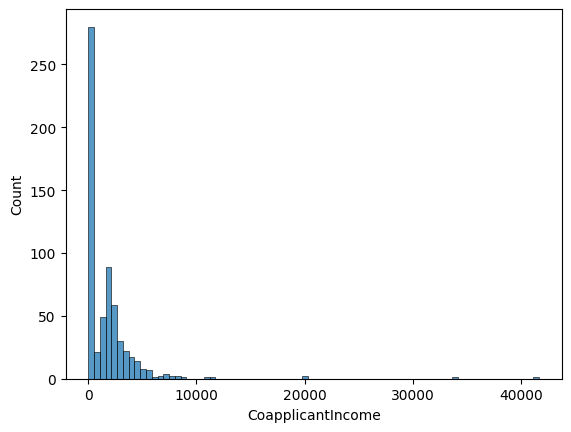

In [14]:
import seaborn as sns
sns.histplot(df['CoapplicantIncome'])

In [15]:
print(len(df['LoanAmount'].unique())) # Numerical continuous column
df['LoanAmount'].unique()

204


array([ nan, 128.,  66., 120., 141., 267.,  95., 158., 168., 349.,  70.,
       109., 200., 114.,  17., 125., 100.,  76., 133., 115., 104., 315.,
       116., 112., 151., 191., 122., 110.,  35., 201.,  74., 106., 320.,
       144., 184.,  80.,  47.,  75., 134.,  96.,  88.,  44., 286.,  97.,
       135., 180.,  99., 165., 258., 126., 312., 136., 172.,  81., 187.,
       113., 176., 130., 111., 167., 265.,  50., 210., 175., 131., 188.,
        25., 137., 160., 225., 216.,  94., 139., 152., 118., 185., 154.,
        85., 259., 194.,  93., 370., 182., 650., 102., 290.,  84., 242.,
       129.,  30., 244., 600., 255.,  98., 275., 121.,  63., 700.,  87.,
       101., 495.,  67.,  73., 260., 108.,  58.,  48., 164., 170.,  83.,
        90., 166., 124.,  55.,  59., 127., 214., 240.,  72.,  60., 138.,
        42., 280., 140., 155., 123., 279., 192., 304., 330., 150., 207.,
       436.,  78.,  54.,  89., 143., 105., 132., 480.,  56., 159., 300.,
       376., 117.,  71., 490., 173.,  46., 228., 30

In [16]:
print(len(df['Loan_Amount_Term'].unique())) # Numerical discrete column
df['Loan_Amount_Term'].unique()

11


array([360., 120., 240.,  nan, 180.,  60., 300., 480.,  36.,  84.,  12.])

In [17]:
print(len(df['Credit_History'].unique())) # Numerical discrete column
df['Credit_History'].unique()

3


array([ 1.,  0., nan])

In [18]:
print(len(df['Property_Area'].unique())) # Categorical ordinal column
df['Property_Area'].unique()

3


array(['Urban', 'Rural', 'Semiurban'], dtype=object)

In [19]:
print(len(df['Loan_Status (Approved)'].unique())) # Categorical nominal column
df['Loan_Status (Approved)'].unique()

2


array(['Y', 'N'], dtype=object)

Columns and their data values
loanid-->nominal,

gender-->Depends on domain,

married-->nominal,

dependents-->ordinal,

education-->nominal,

self-employed-->nominal,

applicantincome-->continuous,

coapplicantincome-->continuous,

loanamount-->continuous,

loan-amount-term-->discrete,

credit-history-->discrete,

property-area-->ordinal(as they are having priorities,urban is getting loan sanctioned),

loan-status-->nominal

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Loan_ID                 614 non-null    object 
 1   Gender                  601 non-null    object 
 2   Married                 611 non-null    object 
 3   Dependents              599 non-null    object 
 4   Education               614 non-null    object 
 5   Self_Employed           582 non-null    object 
 6   ApplicantIncome         614 non-null    int64  
 7   CoapplicantIncome       614 non-null    float64
 8   LoanAmount              592 non-null    float64
 9   Loan_Amount_Term        600 non-null    float64
 10  Credit_History          564 non-null    float64
 11  Property_Area           614 non-null    object 
 12  Loan_Status (Approved)  614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('loan_approved.csv')

13


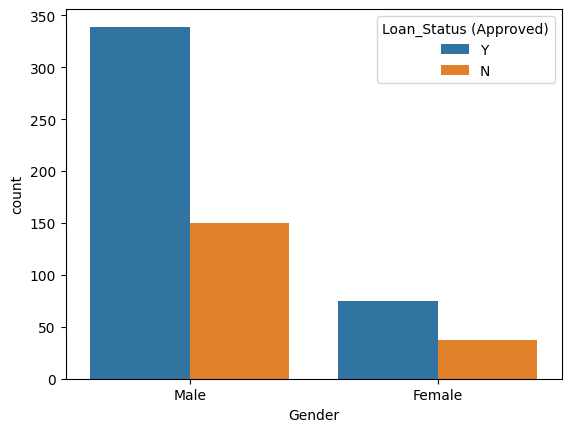

C:\Users\supev\AppData\Local\Temp\ipykernel_42876\3473812529.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Gender"].fillna(df["Gender"].mode()[0], inplace=True)


In [22]:
print(df["Gender"].isna().sum())
sns.countplot(x=df["Gender"],hue=df['Loan_Status (Approved)'])
plt.show()
# Filling with mode because gender is nominal and most frequent value best preserves dataset distribution.
df["Gender"].fillna(df["Gender"].mode()[0], inplace=True)

3


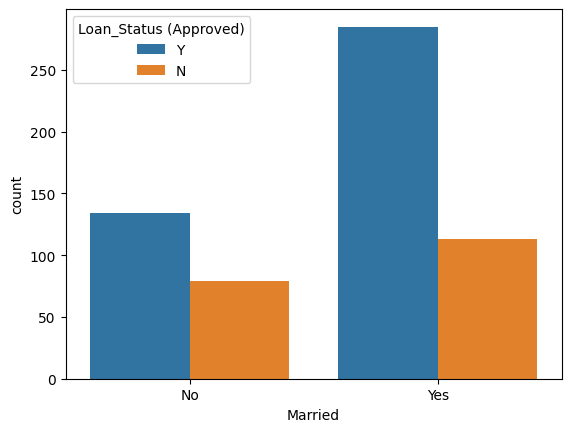

C:\Users\supev\AppData\Local\Temp\ipykernel_42876\3356759228.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Married"].fillna(df["Married"].mode()[0], inplace=True)


In [23]:

print(df["Married"].isna().sum())
sns.countplot(x=df["Married"],hue=df['Loan_Status (Approved)'])
plt.show()
df["Married"].fillna(df["Married"].mode()[0], inplace=True)

15


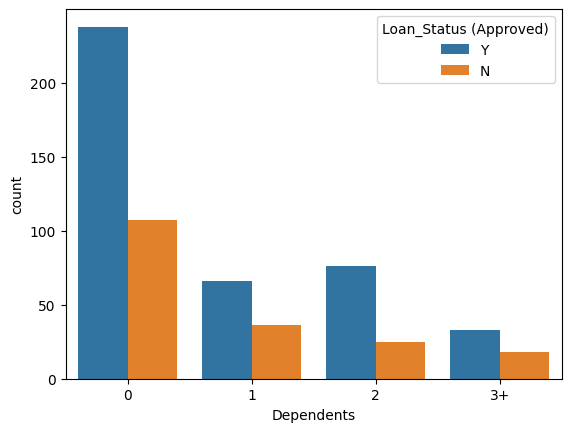

C:\Users\supev\AppData\Local\Temp\ipykernel_42876\238188594.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Dependents"].fillna('3+', inplace=True)


In [24]:
print(df["Dependents"].isna().sum())
sns.countplot(x=df["Dependents"], hue=df['Loan_Status (Approved)'])
plt.show()
#As dependents '3+' has almost same acceptance and rejection rate other parameters will decide the acceptance and rejection so we can fill the missing values with '3+'
df["Dependents"].fillna('3+', inplace=True)

32


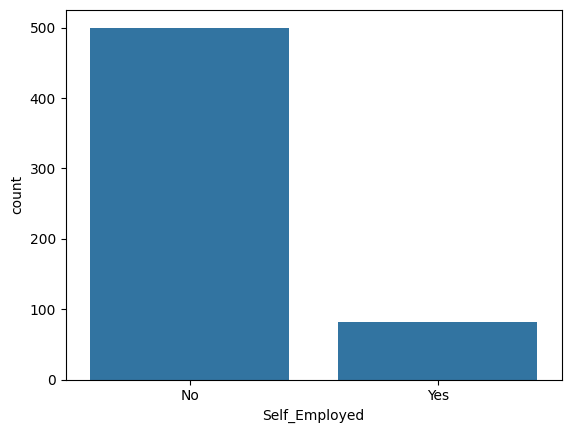

C:\Users\supev\AppData\Local\Temp\ipykernel_42876\4081823607.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Self_Employed"].fillna(df["Self_Employed"].mode()[0], inplace=True)


In [25]:
print(df["Self_Employed"].isna().sum())
sns.countplot(x=df["Self_Employed"])
plt.show()
df["Self_Employed"].fillna(df["Self_Employed"].mode()[0], inplace=True)



22


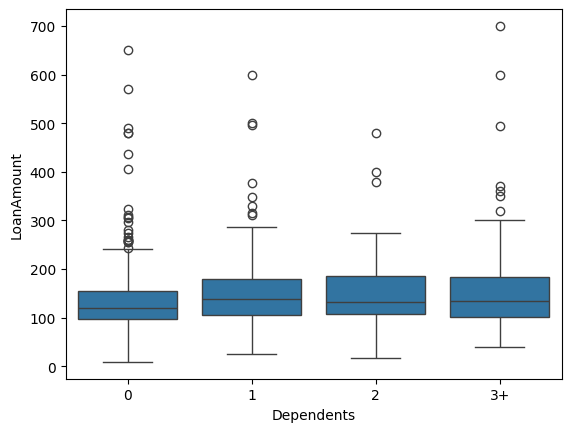

In [26]:
print(df["LoanAmount"].isna().sum())
sns.boxplot(x=df["Dependents"], y=df["LoanAmount"])
plt.show()
# Filling by group median because loan amount is strongly influenced by number of dependents.
df["LoanAmount"] = df["LoanAmount"].fillna(df.groupby("Dependents")["LoanAmount"].transform("median"))


14


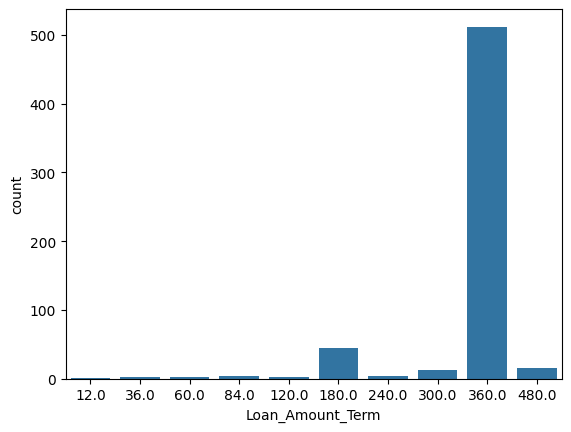

C:\Users\supev\AppData\Local\Temp\ipykernel_42876\3917359843.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].mode()[0], inplace=True)


In [27]:
print(df["Loan_Amount_Term"].isna().sum())
sns.countplot(x=df["Loan_Amount_Term"])
plt.show()
df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].mode()[0], inplace=True)

50


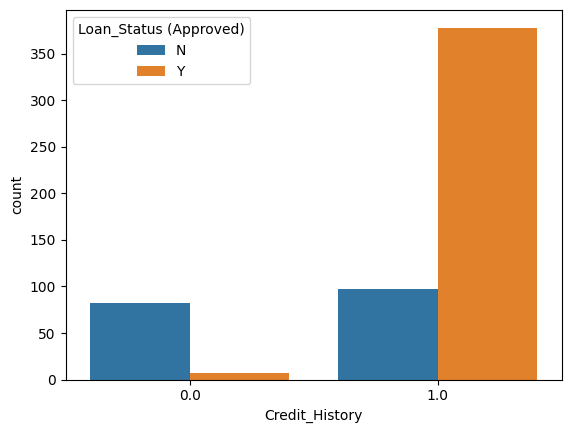

C:\Users\supev\AppData\Local\Temp\ipykernel_42876\3663020923.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Credit_History"].fillna(1, inplace=True)


In [28]:
print(df["Credit_History"].isna().sum())
sns.countplot(x=df["Credit_History"], hue=df["Loan_Status (Approved)"])
plt.show()
df["Credit_History"].fillna(1, inplace=True)

In [29]:
df.isnull().sum()

Loan_ID                   0
Gender                    0
Married                   0
Dependents                0
Education                 0
Self_Employed             0
ApplicantIncome           0
CoapplicantIncome         0
LoanAmount                0
Loan_Amount_Term          0
Credit_History            0
Property_Area             0
Loan_Status (Approved)    0
dtype: int64

# 📖 Data Storytelling – Column-wise Interpretation


### 1. Restaurant_Name  
Each record represents a globally recognized fine-dining restaurant. These names reflect brand value, legacy, and global culinary reputation.

### 2. City  
The city highlights the geographical clustering of luxury dining. Culinary hubs like Paris, Tokyo, New York, and Singapore dominate high-end gastronomy.

### 3. Country  
This column shows how Michelin influence is spread across countries. France, Italy, Japan, and the USA appear frequently, proving their dominance in fine dining.

### 4. Cuisine_Type  
Cuisine type describes the core food identity of each restaurant. French and contemporary cuisines dominate, indicating customer preference for refined culinary traditions.

### 5. Michelin_Stars  
Stars represent the prestige and quality of the restaurant. A higher star rating directly increases demand, trust, and pricing power.

### 6. Average_Price_USD  
This reflects customer spending behavior. Higher prices indicate premium ingredients, elite chefs, and luxury dining experience.

### 7. Chef  
The Chef column represents personal brand value. A famous chef increases restaurant credibility and justifies premium pricing.

### 8. Established_Year  
Older establishments show stability, reputation, and long-term customer trust.

### 9. Seating_Capacity  
This limits customer volume and controls exclusivity. Smaller seating usually results in higher demand and premium pricing.

### 10. Rating  
Customer satisfaction is captured here. Ratings above 4.5 indicate strong service, food quality, and experience consistency.

### 11. Signature_Dish  
This is the main attraction of the restaurant and drives customer interest and brand identity.

### 12. Years_Operating  
Indicates business longevity. More years generally mean strong brand loyalty and consistent performance.

### 13. Price_Category  
Classifies customer affordability level – Budget, Luxury, or Ultra-Luxury. This helps target the right customer segment.

### 14. Star_Category  
Groups restaurants by star levels, simplifying performance comparison.

### 15. Continent  
Shows geographical dominance of luxury dining across Europe, Asia, and North America.



## ✅ Final Business Story Summary

- Michelin-star restaurants thrive in **global metropolitan cities**.
- **Higher Michelin stars = higher price and customer trust**.
- **Renowned chefs act as brand ambassadors**, increasing business value.
- Luxury dining is strongest in **Europe and Asia**.
- **Older restaurants survive through consistency, not trends**.

This storytelling converts raw data into **business intelligence** and helps stakeholders understand **how and why these restaurants succeed**.
